# text2img: stable-diffusion-v1-5 + DreamBooth-LoRA

In [1]:
import sys
import subprocess
import importlib.util

def pip_install(*packages):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])

pip_install(
    "diffusers>=0.35.1",
    "transformers>=4.46.0",
    "accelerate>=0.33.0",
    "peft>=0.12.0",
    "safetensors>=0.4.4",
    "sentencepiece",
    "ftfy",
    "opencv-python",
)

pip_install("--no-deps", "facenet-pytorch")

In [2]:
import os
import math
import random
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import importlib.metadata as md
from packaging.version import Version

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

import torch
import torch.nn.functional as F

from tqdm.auto import tqdm

from transformers import CLIPModel, CLIPProcessor
from facenet_pytorch import MTCNN, InceptionResnetV1

In [3]:
SEED = 555
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

IS_COLAB = importlib.util.find_spec("google.colab") is not None
if IS_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

def ensure_dir(p: Path) -> Path:
    p.mkdir(parents=True, exist_ok=True)
    return p

DEVICE: cuda
Mounted at /content/drive


In [4]:
ROOT = ensure_dir(Path("/content/drive/MyDrive/text2img_self_lab")) if IS_COLAB else ensure_dir(Path("./text2img_self_lab"))
RAW_INSTANCE_DIR = ensure_dir(ROOT / "instance_raw")
INSTANCE_DIR = ensure_dir(ROOT / "instance_prepared")
CLASS_DIR = ensure_dir(ROOT / "class_images")
OUTPUT_DIR = ensure_dir(ROOT / "dreambooth_lora_out")
RESULTS_DIR = ensure_dir(ROOT / "results")
WORK_DIR = ensure_dir(ROOT / "work")

BASE_MODEL_ID = "runwayml/stable-diffusion-v1-5"

INSTANCE_TOKEN = "vitaliy"
CLASS_WORD = "man"
INSTANCE_PROMPT = f"photo of {INSTANCE_TOKEN} {CLASS_WORD}"
CLASS_PROMPT = f"photo of a {CLASS_WORD}"

IMAGE_SIZE = 512
TRAIN_BATCH_SIZE = 1
GRAD_ACCUM_STEPS = 4
TRAIN_STEPS = 1000
CHECKPOINTING_STEPS = 200
LEARNING_RATE = 5e-5
LORA_RANK = 8
NUM_CLASS_IMAGES = 50
PRIOR_LOSS_WEIGHT = 1.0
MIXED_PRECISION = "fp16" if DEVICE.type == "cuda" else "no"

NUM_INFERENCE_STEPS = 50
GUIDANCE_SCALE = 7.5

METRIC_DEVICE = torch.device("cpu")
CLIP_MODEL_ID = "openai/clip-vit-base-patch32"

SHOWCASE_PROMPTS = [
    ("forest", f"{INSTANCE_TOKEN} {CLASS_WORD} in a forest, high quality, realism, portrait photo"),
    ("city", f"{INSTANCE_TOKEN} {CLASS_WORD} in a city, high quality, realism, portrait photo"),
    ("beach", f"{INSTANCE_TOKEN} {CLASS_WORD} in a beach, high quality, realism, portrait photo"),
    ("cyberpunk", f"{INSTANCE_TOKEN} {CLASS_WORD} in a cyberpunk street at night, high quality, realism, portrait photo"),
    ("elf_city", f"{INSTANCE_TOKEN} {CLASS_WORD} in an elven city, high quality, realism, portrait photo"),
    ("moon", f"{INSTANCE_TOKEN} {CLASS_WORD} on the moon, high quality, realism, portrait photo"),
]

GENERIC_PROMPTS = [
    ("forest", f"{CLASS_WORD} in a forest, high quality, realism, portrait photo"),
    ("city", f"{CLASS_WORD} in a city, high quality, realism, portrait photo"),
    ("beach", f"{CLASS_WORD} in a beach, high quality, realism, portrait photo"),
]

In [5]:
def list_images(folder: Path) -> List[Path]:
    exts = {".jpg", ".jpeg", ".png", ".webp"}
    return sorted([p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in exts])

def show_pil_grid(images: List[Image.Image], titles: Optional[List[str]] = None, cols: int = 4, size: Tuple[int, int] = (12, 10)):
    if not images:
        print("No images to display")
        return

    n = len(images)
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=size)
    axes = np.array(axes).reshape(rows, cols)

    for ax in axes.ravel():
        ax.axis("off")

    for i, img in enumerate(images):
        ax = axes[i // cols, i % cols]
        ax.imshow(img)
        ax.axis("off")
        if titles is not None and i < len(titles):
            ax.set_title(titles[i], fontsize=10)

    plt.tight_layout()
    plt.show()

def prepare_square_image(img: Image.Image, size: int = 512) -> Image.Image:
    img = ImageOps.exif_transpose(img).convert("RGB")
    scale = size / min(img.size)
    new_w = max(size, int(round(img.width * scale)))
    new_h = max(size, int(round(img.height * scale)))
    img = img.resize((new_w, new_h), Image.Resampling.LANCZOS)

    left = (new_w - size) // 2
    top = (new_h - size) // 2
    return img.crop((left, top, left + size, top + size))

def prepare_instance_images(src_dir: Path, dst_dir: Path, size: int = 512) -> List[Path]:
    ensure_dir(dst_dir)
    src_paths = list_images(src_dir)

    out_paths = []
    for i, src in enumerate(src_paths):
        with Image.open(src) as img0:
            img = prepare_square_image(img0, size=size)
        dst = dst_dir / f"instance_{i:03d}.png"
        img.save(dst)
        out_paths.append(dst)

    return out_paths

def find_lora_weights(output_dir: Path) -> Optional[Path]:
    for name in ["pytorch_lora_weights.safetensors", "pytorch_lora_weights.bin", "adapter_model.safetensors"]:
        p = output_dir / name
        if p.exists():
            return p
    return None

## Подготовка данных

Фото должны лежать в `instance_raw/`

raw instance images: 11
prepared instance images: 11


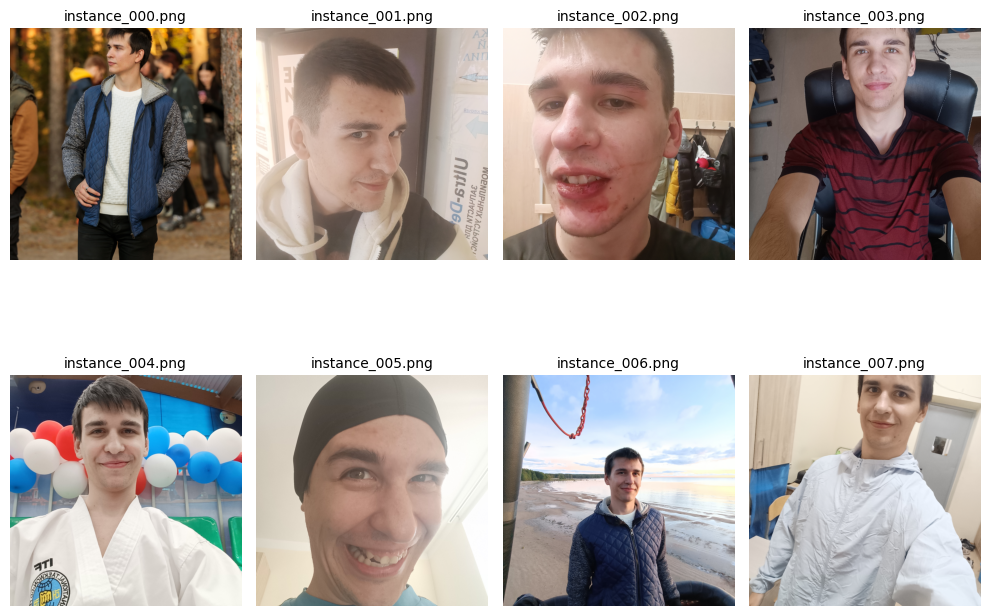

In [6]:
raw_paths = list_images(RAW_INSTANCE_DIR)
print("raw instance images:", len(raw_paths))
assert len(raw_paths) >= 4, f"At least 4 photos are required in {RAW_INSTANCE_DIR}"

prepared_paths = prepare_instance_images(RAW_INSTANCE_DIR, INSTANCE_DIR, size=IMAGE_SIZE)
print("prepared instance images:", len(prepared_paths))

preview_imgs = []
for p in prepared_paths[:min(8, len(prepared_paths))]:
    with Image.open(p) as img0:
        preview_imgs.append(img0.convert("RGB"))
show_pil_grid(preview_imgs, titles=[p.name for p in prepared_paths[:len(preview_imgs)]], cols=4, size=(10, 8))

## Обучение DreamBooth LoRA с prior preservation


In [7]:
def ensure_diffusers_repo(base_dir: Path) -> Path:
    repo_dir = base_dir / "diffusers"
    if not repo_dir.exists():
        subprocess.check_call([
            "git", "clone", "--depth", "1",
            "https://github.com/huggingface/diffusers.git",
            str(repo_dir),
        ])
    return repo_dir


def ensure_dreambooth_requirements(repo_dir: Path) -> None:
    req = repo_dir / "examples" / "dreambooth" / "requirements.txt"

    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-e", str(repo_dir)])

    if req.exists():
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", str(req)])

    try:
        peft_ver = Version(md.version("peft"))
    except md.PackageNotFoundError:
        peft_ver = Version("0")

    if peft_ver < Version("0.17.0"):
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", "peft>=0.17.0"])


def run_dreambooth_lora():
    repo_dir = ensure_diffusers_repo(WORK_DIR)
    ensure_dreambooth_requirements(repo_dir)

    script = repo_dir / "examples" / "dreambooth" / "train_dreambooth_lora.py"
    assert script.exists(), f"Training script not found: {script}"

    cmd = [
        sys.executable, "-m", "accelerate.commands.launch",
        "--num_processes", "1",
        "--mixed_precision", MIXED_PRECISION,
        str(script),
        "--pretrained_model_name_or_path", BASE_MODEL_ID,
        "--instance_data_dir", str(INSTANCE_DIR),
        "--class_data_dir", str(CLASS_DIR),
        "--output_dir", str(OUTPUT_DIR),
        "--instance_prompt", INSTANCE_PROMPT,
        "--class_prompt", CLASS_PROMPT,
        "--with_prior_preservation",
        "--prior_loss_weight", str(PRIOR_LOSS_WEIGHT),
        "--num_class_images", str(NUM_CLASS_IMAGES),
        "--resolution", str(IMAGE_SIZE),
        "--train_batch_size", str(TRAIN_BATCH_SIZE),
        "--gradient_accumulation_steps", str(GRAD_ACCUM_STEPS),
        "--learning_rate", str(LEARNING_RATE),
        "--lr_scheduler", "constant",
        "--lr_warmup_steps", "0",
        "--max_train_steps", str(TRAIN_STEPS),
        "--checkpointing_steps", str(CHECKPOINTING_STEPS),
        "--rank", str(LORA_RANK),
        "--mixed_precision", MIXED_PRECISION,
        "--gradient_checkpointing",
        "--dataloader_num_workers", "0",
        "--pre_compute_text_embeddings",
        "--seed", str(SEED),
    ]

    if DEVICE.type == "cuda":
        cmd += ["--allow_tf32"]

    env = os.environ.copy()
    env["TOKENIZERS_PARALLELISM"] = "false"
    env["PYTHONUNBUFFERED"] = "1"

    print("Running command:")
    print(" ".join(cmd))

    process = subprocess.Popen(
        cmd,
        cwd=str(repo_dir),
        env=env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    assert process.stdout is not None
    for line in process.stdout:
        print(line, end="")

    return_code = process.wait()
    if return_code != 0:
        raise RuntimeError(f"DreamBooth LoRA training failed with exit code {return_code}")


lora_path = find_lora_weights(OUTPUT_DIR)
if lora_path is not None:
    print("Using saved LoRA:", lora_path)
else:
    print("Training DreamBooth LoRA from scratch...")
    run_dreambooth_lora()
    lora_path = find_lora_weights(OUTPUT_DIR)

assert lora_path is not None, "LoRA weights were not found after training"
print("LoRA ready:", lora_path)

Using saved LoRA: /content/drive/MyDrive/text2img_self_lab/dreambooth_lora_out/pytorch_lora_weights.safetensors
LoRA ready: /content/drive/MyDrive/text2img_self_lab/dreambooth_lora_out/pytorch_lora_weights.safetensors


## Генерация изображений

In [8]:
repo_dir = ensure_diffusers_repo(WORK_DIR)
src_dir = repo_dir / "src"

for name in list(sys.modules.keys()):
    if name == "diffusers" or name.startswith("diffusers."):
        del sys.modules[name]

if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler

def load_personalized_pipe() -> StableDiffusionPipeline:
    torch_dtype = torch.float16 if DEVICE.type == "cuda" else torch.float32

    pipe = StableDiffusionPipeline.from_pretrained(
        BASE_MODEL_ID,
        torch_dtype=torch_dtype,
        safety_checker=None,
    )
    pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)

    if hasattr(pipe, "safety_checker"):
        pipe.safety_checker = None
        pipe.requires_safety_checker = False

    assert lora_path is not None and Path(lora_path).exists(), "LoRA weights not found"
    pipe.load_lora_weights(str(Path(lora_path).parent), weight_name=Path(lora_path).name)

    pipe = pipe.to(DEVICE)
    pipe.set_progress_bar_config(disable=False)
    return pipe


@torch.no_grad()
def generate_from_prompts(
    pipe: StableDiffusionPipeline,
    prompts: List[Tuple[str, str]],
    out_dir: Path,
    guidance_scale: float = GUIDANCE_SCALE,
    num_inference_steps: int = NUM_INFERENCE_STEPS,
    lora_scale: float = 1.0,
) -> List[Dict[str, object]]:
    ensure_dir(out_dir)
    results = []

    for i, (name, prompt) in enumerate(prompts):
        seed_i = SEED + i
        generator = torch.Generator(device=DEVICE).manual_seed(seed_i)

        image = pipe(
            prompt=prompt,
            num_inference_steps=num_inference_steps,
            guidance_scale=guidance_scale,
            generator=generator,
            cross_attention_kwargs={"scale": lora_scale},
        ).images[0]

        dst = out_dir / f"{i:02d}_{name}.png"
        image.save(dst)

        results.append({
            "name": name,
            "prompt": prompt,
            "seed": seed_i,
            "path": str(dst),
            "image": image,
        })

    return results


pipe = load_personalized_pipe()
print("Pipeline loaded")
print("LoRA:", lora_path)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its resul

Pipeline loaded
LoRA: /content/drive/MyDrive/text2img_self_lab/dreambooth_lora_out/pytorch_lora_weights.safetensors


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

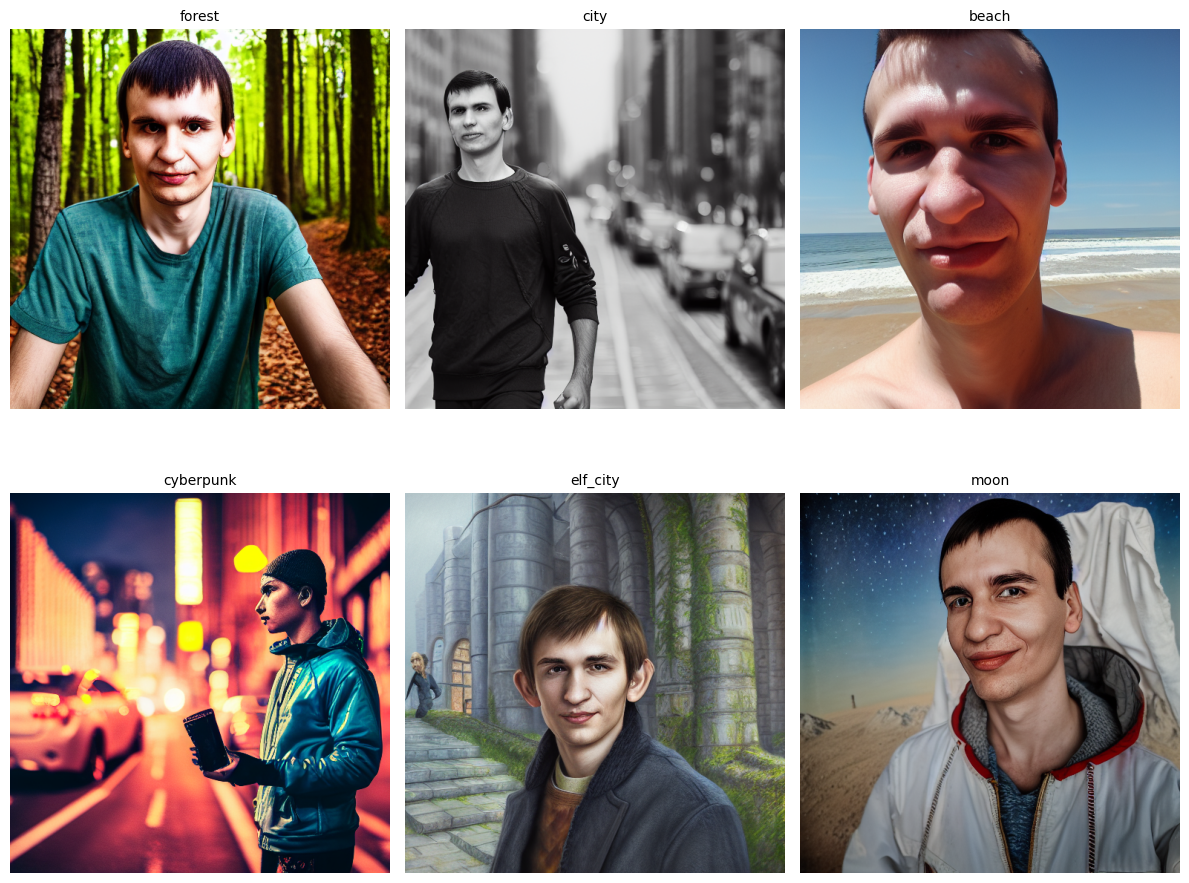

In [9]:
showcase_results = generate_from_prompts(pipe, SHOWCASE_PROMPTS, RESULTS_DIR / "showcase")
show_pil_grid(
    [row["image"] for row in showcase_results],
    titles=[row["name"] for row in showcase_results],
    cols=3,
    size=(12, 10),
)

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Token prompts: forest / city / beach


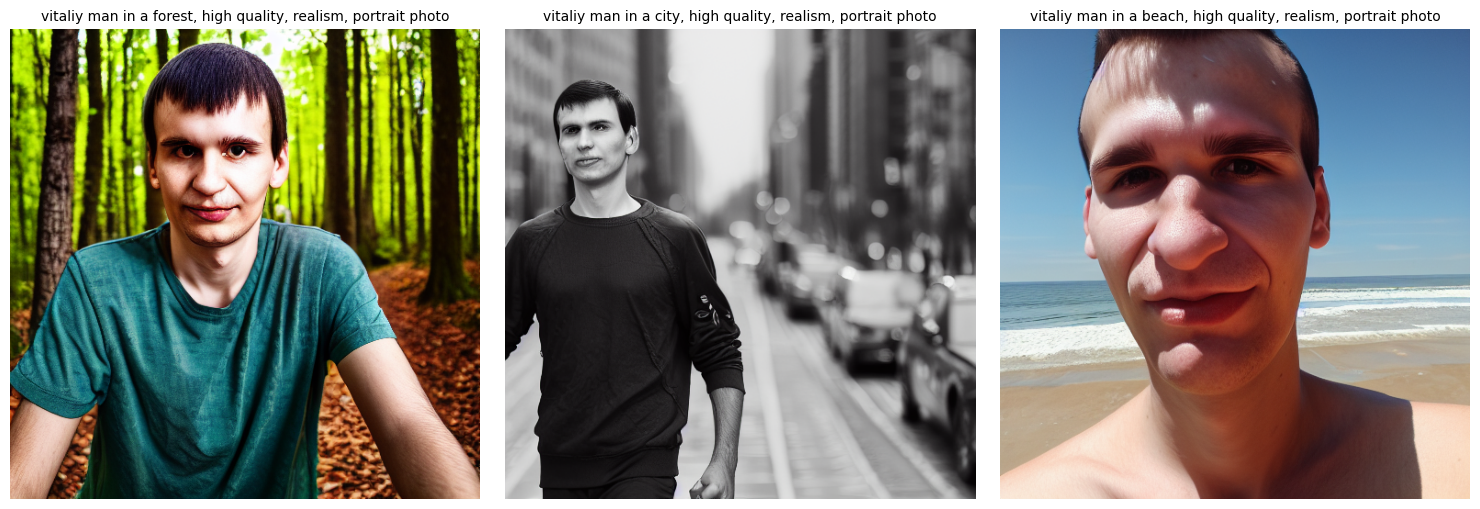

Generic prompts without token: forest / city / beach


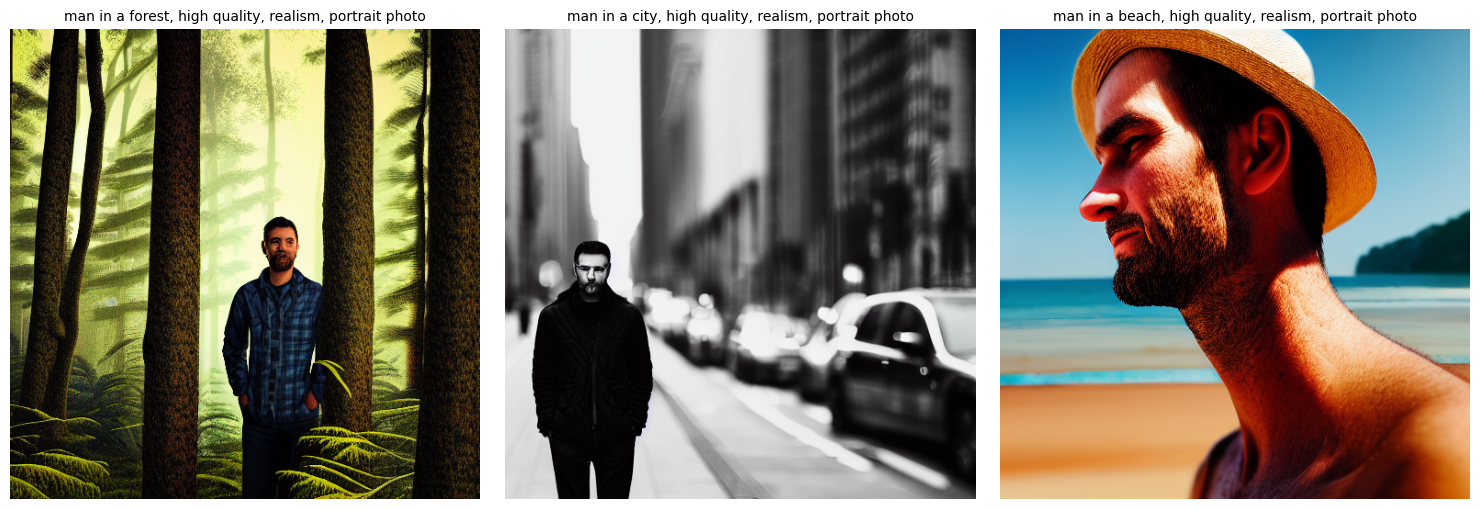

In [10]:
gender_results = generate_from_prompts(pipe, GENERIC_PROMPTS, RESULTS_DIR / "generic_gender")

print("Token prompts: forest / city / beach")
show_pil_grid(
    [row["image"] for row in showcase_results[:3]],
    titles=[row["prompt"] for row in showcase_results[:3]],
    cols=3,
    size=(15, 5),
)

print("Generic prompts without token: forest / city / beach")
show_pil_grid(
    [row["image"] for row in gender_results],
    titles=[row["prompt"] for row in gender_results],
    cols=3,
    size=(15, 5),
)

## Метрики
1. **CLIP text-image similarity** — насколько изображение соответствует текстовому промпту.  
2. **Face identity cosine similarity** — насколько сгенерированное лицо похоже на исходные фото человека.  
3. **Variance of Laplacian** — мера визуальной резкости; чем выше, тем меньше размытость.

In [11]:
def build_clip_tools(device: torch.device):
    clip_model = CLIPModel.from_pretrained(CLIP_MODEL_ID).to(device).eval()
    clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_ID)
    return clip_model, clip_processor

@torch.no_grad()
def clip_similarity_scores(
    images: List[Image.Image],
    prompts: List[str],
    clip_model: CLIPModel,
    clip_processor: CLIPProcessor,
    device: torch.device,
) -> List[float]:
    scores = []
    for img, prompt in zip(images, prompts):
        inputs = clip_processor(text=[prompt], images=[img], return_tensors="pt", padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        outputs = clip_model(**inputs)

        img_emb = outputs.image_embeds
        txt_emb = outputs.text_embeds
        img_emb = img_emb / img_emb.norm(dim=-1, keepdim=True)
        txt_emb = txt_emb / txt_emb.norm(dim=-1, keepdim=True)

        scores.append(float((img_emb * txt_emb).sum(dim=-1).item()))
    return scores

def build_face_tools(device: torch.device):
    mtcnn = MTCNN(image_size=160, margin=14, post_process=True, device=device)
    facenet = InceptionResnetV1(pretrained="vggface2").eval().to(device)
    return mtcnn, facenet

@torch.no_grad()
def extract_face_embedding(
    img: Image.Image,
    mtcnn: MTCNN,
    facenet: InceptionResnetV1,
    device: torch.device,
) -> Optional[np.ndarray]:
    face = mtcnn(img)
    if face is None:
        return None
    face = face.unsqueeze(0).to(device)
    emb = facenet(face)
    emb = emb / emb.norm(dim=-1, keepdim=True)
    return emb.squeeze(0).cpu().numpy()

@torch.no_grad()
def build_reference_identity(
    image_paths: List[Path],
    mtcnn: MTCNN,
    facenet: InceptionResnetV1,
    device: torch.device,
) -> np.ndarray:
    embs = []
    for p in image_paths:
        with Image.open(p) as img0:
            emb = extract_face_embedding(img0.convert("RGB"), mtcnn, facenet, device)
        if emb is not None:
            embs.append(emb)
    assert len(embs) > 0, "Failed to extract a face embedding from the reference photos"
    ref = np.mean(np.stack(embs, axis=0), axis=0)
    ref = ref / (np.linalg.norm(ref) + 1e-12)
    return ref

def cosine_similarity_np(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.dot(a, b) / ((np.linalg.norm(a) + 1e-12) * (np.linalg.norm(b) + 1e-12)))

def sharpness_score(img: Image.Image) -> float:
    gray = np.asarray(img.convert("L"))
    return float(cv2.Laplacian(gray, cv2.CV_64F).var())

def summarize_metric_rows(rows: List[Dict[str, object]]) -> Dict[str, float]:
    clip_vals = [float(r["clip_sim"]) for r in rows]
    id_vals = [float(r["identity_sim"]) for r in rows if not math.isnan(float(r["identity_sim"]))]
    sharp_vals = [float(r["sharpness"]) for r in rows]

    return {
        "clip_sim_mean": float(np.mean(clip_vals)),
        "identity_sim_mean": float(np.mean(id_vals)) if id_vals else float("nan"),
        "sharpness_mean": float(np.mean(sharp_vals)),
    }

In [12]:
clip_model, clip_processor = build_clip_tools(METRIC_DEVICE)
mtcnn, facenet = build_face_tools(METRIC_DEVICE)
reference_identity = build_reference_identity(prepared_paths, mtcnn, facenet, METRIC_DEVICE)

showcase_metric_rows = []
for row in showcase_results:
    img = row["image"]
    prompt = row["prompt"]

    clip_score = clip_similarity_scores([img], [prompt], clip_model, clip_processor, METRIC_DEVICE)[0]
    gen_emb = extract_face_embedding(img, mtcnn, facenet, METRIC_DEVICE)
    identity_sim = cosine_similarity_np(reference_identity, gen_emb) if gen_emb is not None else float("nan")
    sharpness = sharpness_score(img)

    showcase_metric_rows.append({
        "name": row["name"],
        "prompt": prompt,
        "clip_sim": clip_score,
        "identity_sim": identity_sim,
        "sharpness": sharpness,
    })

generic_metric_rows = []
for row in gender_results:
    img = row["image"]
    prompt = row["prompt"]
    clip_score = clip_similarity_scores([img], [prompt], clip_model, clip_processor, METRIC_DEVICE)[0]
    sharpness = sharpness_score(img)
    generic_metric_rows.append({
        "name": row["name"],
        "prompt": prompt,
        "clip_sim": clip_score,
        "sharpness": sharpness,
    })

showcase_summary = summarize_metric_rows(showcase_metric_rows)
generic_clip_mean = float(np.mean([r["clip_sim"] for r in generic_metric_rows]))
generic_sharp_mean = float(np.mean([r["sharpness"] for r in generic_metric_rows]))

print("Personalized images:")
for r in showcase_metric_rows:
    print({
        "name": r["name"],
        "clip_sim": round(r["clip_sim"], 4),
        "identity_sim": None if math.isnan(r["identity_sim"]) else round(r["identity_sim"], 4),
        "sharpness": round(r["sharpness"], 2),
    })

print("\nAverages for personalized images:")
print({k: (round(v, 4) if isinstance(v, float) and not math.isnan(v) else v) for k, v in showcase_summary.items()})

print("\nGeneric prompts without token:")
for r in generic_metric_rows:
    print({
        "name": r["name"],
        "clip_sim": round(r["clip_sim"], 4),
        "sharpness": round(r["sharpness"], 2),
    })

print("\nAverages for generic prompts:")
print({
    "clip_sim_mean": round(generic_clip_mean, 4),
    "sharpness_mean": round(generic_sharp_mean, 2),
})

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

  0%|          | 0.00/107M [00:00<?, ?B/s]

Personalized images:
{'name': 'forest', 'clip_sim': 0.3483, 'identity_sim': 0.5469, 'sharpness': 819.49}
{'name': 'city', 'clip_sim': 0.2735, 'identity_sim': 0.497, 'sharpness': 332.77}
{'name': 'beach', 'clip_sim': 0.3034, 'identity_sim': 0.5841, 'sharpness': 258.04}
{'name': 'cyberpunk', 'clip_sim': 0.2685, 'identity_sim': 0.1373, 'sharpness': 1030.5}
{'name': 'elf_city', 'clip_sim': 0.3313, 'identity_sim': 0.6286, 'sharpness': 608.72}
{'name': 'moon', 'clip_sim': 0.2989, 'identity_sim': 0.6564, 'sharpness': 508.23}

Averages for personalized images:
{'clip_sim_mean': 0.304, 'identity_sim_mean': 0.5084, 'sharpness_mean': 592.9583}

Generic prompts without token:
{'name': 'forest', 'clip_sim': 0.3009, 'sharpness': 3377.94}
{'name': 'city', 'clip_sim': 0.3024, 'sharpness': 229.2}
{'name': 'beach', 'clip_sim': 0.3317, 'sharpness': 1051.38}

Averages for generic prompts:
{'clip_sim_mean': 0.3117, 'sharpness_mean': 1552.84}


## Вывод

В работе выполнена персонализация предобученной text2img-модели с помощью **DreamBooth LoRA**. Изображения генерируются по уникальному токену в разных окружениях и при этом сохраняется способность создавать обычных людей.
